In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Загружаем датасет
df = pd.read_csv('retail_customer_segmentation.csv')

In [4]:
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.21,63,121.43,0.82,66.82,0.12,0.02,77.30,2.00,Card,Semi-Urban,Occasional
1,9428,54,54730.64,67,572.55,3.18,137.09,0.26,0.43,92.13,2.00,Wallet,Urban,Occasional
2,200,44,58268.12,57,266.59,2.71,71.80,0.28,0.01,155.19,1.00,UPI,Rural,Occasional
3,12448,54,64829.80,40,691.45,5.55,105.50,0.10,0.40,113.92,0.00,Wallet,Rural,High_Value
4,39490,28,27431.47,15,832.66,1.35,354.57,0.41,0.04,50.12,1.00,Card,Semi-Urban,Occasional


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  object 
 12  region                 50000 non-null  object 
 13  customer_segment       50000 non-null  object 
dtypes: float64(8), int64(3), object(3)
memory usage: 5.3+ 

In [6]:
# Общая статистика по числовым колонкам
df.describe()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.00,50000.00,46925.00,50000.00,47480.00,48021.00,50000.00,47451.00,47513.00,46066.00,48012.00
mean,25000.50,44.00,44542.62,36.48,337.29,4.91,77.38,0.28,0.15,61.78,1.49
std,14433.90,15.27,30537.95,20.79,204.63,3.42,70.53,0.16,0.11,41.74,1.22
min,1.00,18.00,2946.32,1.00,8.07,0.02,0.94,0.00,0.00,0.24,0.00
25%,12500.75,31.00,24373.24,18.00,192.07,2.46,32.02,0.16,0.06,31.08,1.00
50%,25000.50,44.00,36787.73,36.00,297.48,4.16,56.60,0.26,0.12,52.68,1.00
75%,37500.25,57.00,55497.25,55.00,439.11,6.53,98.83,0.39,0.21,82.55,2.00
max,50000.00,70.00,530788.32,72.00,3026.34,67.68,1289.43,0.93,0.83,406.81,9.00


In [7]:
# Уникальные значения категориальных колонок
print('Сегменты:', df['customer_segment'].unique())
print('Регионы:', df['region'].unique())
print('Способы оплаты:', df['payment_method'].unique())

Сегменты: ['Occasional' 'High_Value' 'Loyal' 'Regular']
Регионы: ['Semi-Urban' 'Urban' 'Rural']
Способы оплаты: ['Card' 'Wallet' 'UPI']


## Часть 2 — Очистка данных

In [8]:
# Проверяем пропуски
df.isnull().sum()

customer_id                 0
age                         0
annual_income            3075
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64

In [9]:
# Фиксируем размер до очистки
before = len(df)
print(f'Строк до очистки: {before}')

Строк до очистки: 50000


In [10]:
# Удаляем дубликаты
df = df.drop_duplicates()
print(f'Удалено дублей: {before - len(df)}')

Удалено дублей: 0


In [11]:
# Заполняем пропуски в числовых колонках медианой
num_cols = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
            'discount_usage_rate', 'return_rate',
            'browsing_time_minutes', 'support_interactions']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print('Пропуски после заполнения:')
df.isnull().sum()

Пропуски после заполнения:


customer_id              0
age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

In [12]:
# Создаём новый признак — расчётный LTV клиента
df['estimated_ltv'] = df['avg_order_value'] * df['purchase_frequency'] * df['months_active']

df[['customer_id', 'customer_segment', 'estimated_ltv']].head()

,customer_id,customer_segment,estimated_ltv
0,33554,Occasional,3440.44
1,9428,Occasional,29176.17
2,200,Occasional,11103.43
3,12448,High_Value,23438.05
4,39490,Occasional,7171.44


In [13]:
print(f'Строк после очистки: {len(df)}')
print(f'Удалено всего: {before - len(df)}')

Строк после очистки: 50000
Удалено всего: 0


## Часть 3 — Разведочный анализ (EDA)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13208\1959877936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')


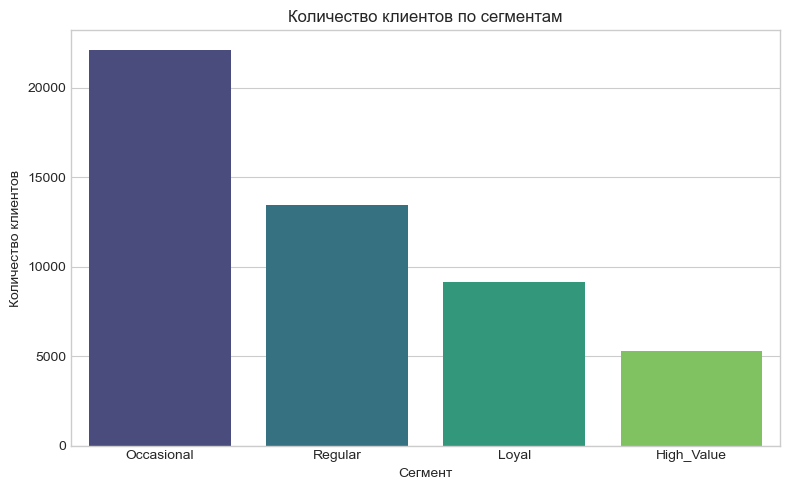

customer_segment
Occasional    22109
Regular       13455
Loyal          9163
High_Value     5273
Name: count, dtype: int64


In [15]:
# Распределение клиентов по сегментам
segment_counts = df['customer_segment'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Количество клиентов по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

print(segment_counts)
# Вывод: Occasional — самый большой сегмент (44%), High_Value — наименьший (10.5%)

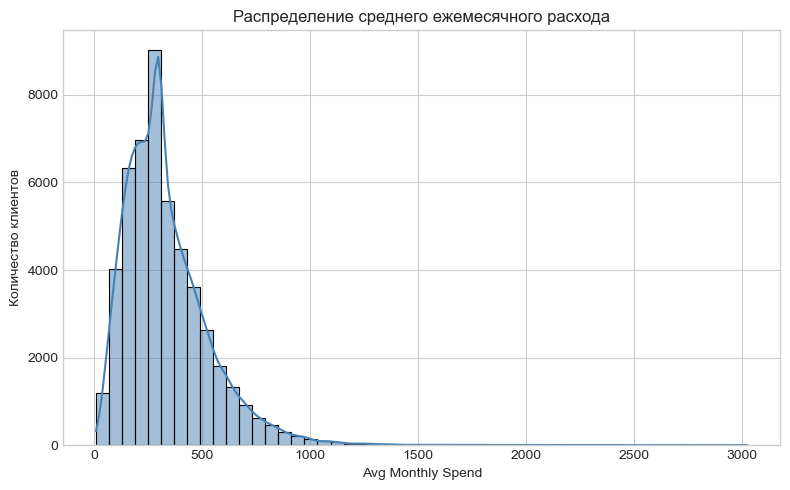

In [18]:
# Распределение среднего ежемесячного расхода
plt.figure(figsize=(8, 5))
sns.histplot(df['avg_monthly_spend'], bins=50, kde=True, color='steelblue')
plt.title('Распределение среднего ежемесячного расхода')
plt.xlabel('Avg Monthly Spend')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

# Вывод: большинство клиентов тратят 150–500 в месяц, есть выбросы выше 2000

C:\Users\Admin\AppData\Local\Temp\ipykernel_13208\1265035592.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='customer_segment', y='avg_monthly_spend',


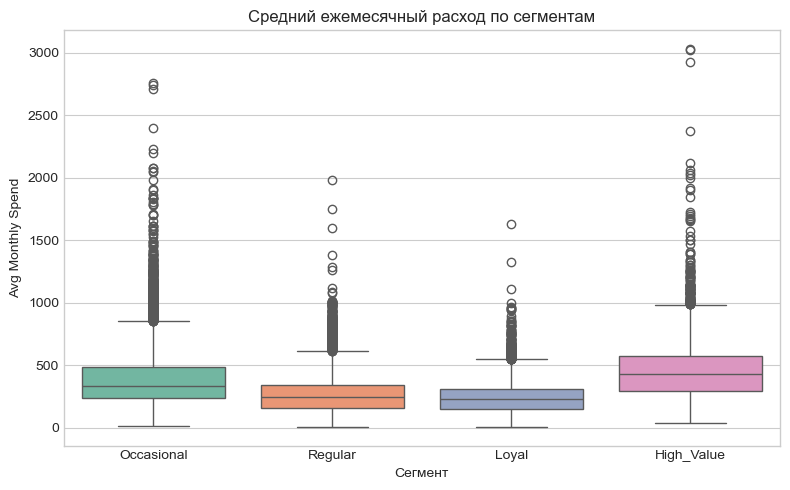

In [19]:
# Средний чек по сегментам
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='customer_segment', y='avg_monthly_spend',
            order=['Occasional','Regular','Loyal','High_Value'], palette='Set2')
plt.title('Средний ежемесячный расход по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Avg Monthly Spend')
plt.tight_layout()
plt.show()

# Вывод: High_Value тратит значительно больше остальных сегментов

C:\Users\Admin\AppData\Local\Temp\ipykernel_13208\3703661942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='avg_monthly_spend',


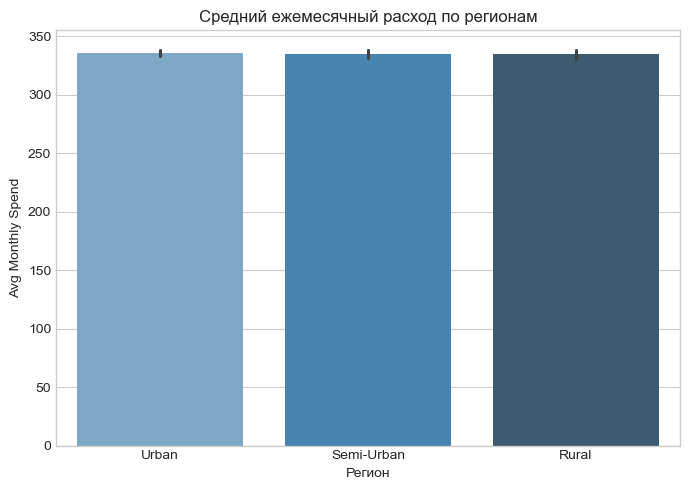

In [20]:
# Средний расход по регионам
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='region', y='avg_monthly_spend',
            order=['Urban','Semi-Urban','Rural'], palette='Blues_d')
plt.title('Средний ежемесячный расход по регионам')
plt.xlabel('Регион')
plt.ylabel('Avg Monthly Spend')
plt.tight_layout()
plt.show()

# Вывод: Urban-клиенты тратят больше всего, Rural — меньше всего

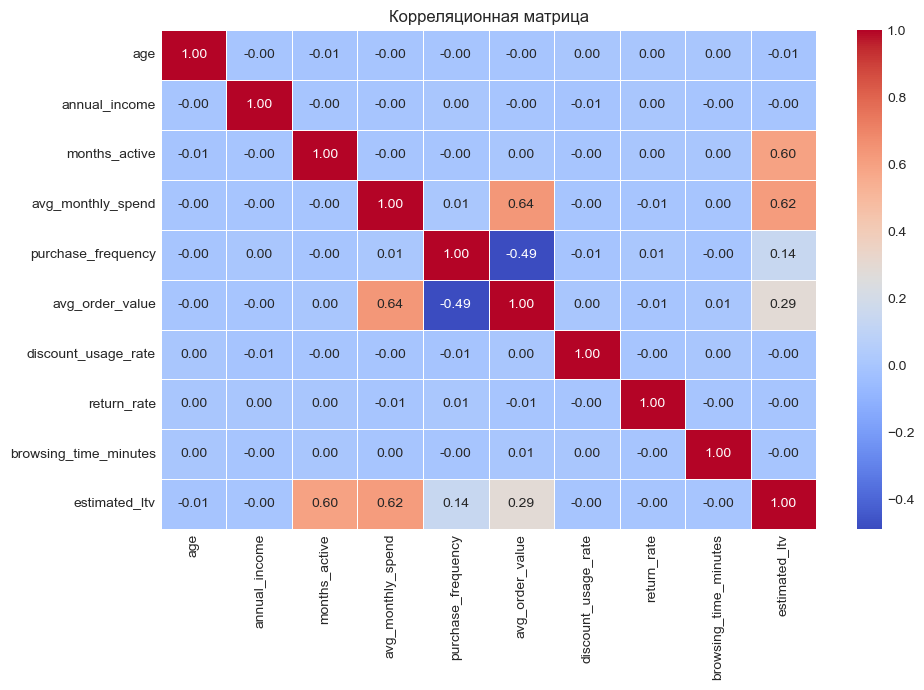

In [21]:
# Корреляционная матрица числовых признаков
num_df = df[['age', 'annual_income', 'months_active', 'avg_monthly_spend',
             'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
             'return_rate', 'browsing_time_minutes', 'estimated_ltv']]

plt.figure(figsize=(10, 7))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

# Вывод: avg_order_value и purchase_frequency сильнее всего влияют на estimated_ltv

## Часть 4 — Ключевые метрики

In [22]:
# Средний LTV по сегментам
ltv_by_segment = df.groupby('customer_segment')['estimated_ltv'].mean().sort_values(ascending=False).reset_index()
ltv_by_segment.columns = ['Сегмент', 'Средний LTV']
ltv_by_segment['Средний LTV'] = ltv_by_segment['Средний LTV'].round(0)

print(ltv_by_segment)
# Вывод: High_Value имеет LTV в разы выше Occasional

      Сегмент  Средний LTV
0  High_Value     22241.00
1       Loyal      9844.00
2  Occasional      8168.00
3     Regular      6748.00


In [23]:
# Retention Rate — доля клиентов активных более 12 месяцев
retained = df[df['months_active'] > 12]['customer_id'].nunique()
total = df['customer_id'].nunique()
retention_rate = retained / total

print(f'Retention Rate: {retention_rate:.1%}')
# Вывод: показывает какая доля клиентов остаётся дольше года

Retention Rate: 83.4%


In [24]:
# Сводная таблица метрик по сегментам
summary = df.groupby('customer_segment').agg(
    customers=('customer_id', 'count'),
    avg_monthly_spend=('avg_monthly_spend', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    avg_return_rate=('return_rate', 'mean'),
    avg_discount_usage=('discount_usage_rate', 'mean'),
    avg_ltv=('estimated_ltv', 'mean')
).round(2)

summary

,customers,avg_monthly_spend,avg_order_value,avg_return_rate,avg_discount_usage,avg_ltv
customer_segment,,,,,,
High_Value,5273,463.77,60.06,0.15,0.28,22241.32
Loyal,9163,245.25,35.89,0.15,0.29,9844.01
Occasional,22109,381.60,111.54,0.15,0.28,8168.05
Regular,13455,270.16,56.27,0.15,0.29,6747.87


## Часть 5 — Линейная регрессия

In [26]:
# Цель: предсказать avg_monthly_spend по характеристикам клиента
features = ['age', 'annual_income', 'months_active', 'purchase_frequency', 'avg_order_value']
target = 'avg_monthly_spend'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [28]:
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R²  = {r2:.3f}   — модель объясняет {r2*100:.1f}% вариации расходов')
print(f'MAE = {mae:.2f}  — средняя ошибка предсказания')

R²  = 0.546   — модель объясняет 54.6% вариации расходов
MAE = 92.14  — средняя ошибка предсказания


C:\Users\Admin\AppData\Local\Temp\ipykernel_13208\2957499229.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Коэффициент', y='Признак', palette='RdBu')


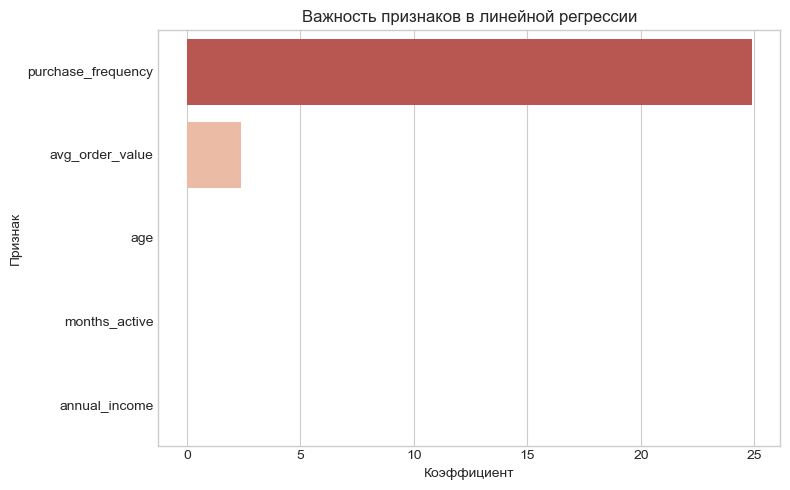

In [29]:
# Важность признаков
coef_df = pd.DataFrame({'Признак': features, 'Коэффициент': model.coef_})
coef_df = coef_df.reindex(coef_df['Коэффициент'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='Коэффициент', y='Признак', palette='RdBu')
plt.title('Важность признаков в линейной регрессии')
plt.tight_layout()
plt.show()

# Вывод: purchase_frequency и avg_order_value — главные предикторы расходов

## Часть 6 — Проверка гипотез

In [30]:
# Гипотеза 1: Urban-клиенты тратят больше, чем Rural
urban = df[df['region'] == 'Urban']['avg_monthly_spend']
rural = df[df['region'] == 'Rural']['avg_monthly_spend']

t_stat, p_value = stats.ttest_ind(urban, rural)

print(f'Среднее Urban: {urban.mean():.2f}')
print(f'Среднее Rural: {rural.mean():.2f}')
print(f'p-value = {p_value:.4f}')

if p_value < 0.05:
    print('✅ Гипотеза подтверждена — разница статистически значима')
else:
    print('❌ Гипотеза не подтверждена — разница случайна')

Среднее Urban: 335.84
Среднее Rural: 334.63
p-value = 0.6093
❌ Гипотеза не подтверждена — разница случайна


In [31]:
# Гипотеза 2: Клиенты с высоким discount_usage тратят меньше
high_discount = df[df['discount_usage_rate'] > 0.5]['avg_order_value']
low_discount  = df[df['discount_usage_rate'] <= 0.5]['avg_order_value']

t_stat, p_value = stats.ttest_ind(high_discount, low_discount)

print(f'Средний чек (высокий дисконт): {high_discount.mean():.2f}')
print(f'Средний чек (низкий дисконт):  {low_discount.mean():.2f}')
print(f'p-value = {p_value:.4f}')

if p_value < 0.05:
    print('✅ Гипотеза подтверждена — скидки снижают средний чек')
else:
    print('❌ Гипотеза не подтверждена — разница случайна')

Средний чек (высокий дисконт): 78.94
Средний чек (низкий дисконт):  77.20
p-value = 0.0947
❌ Гипотеза не подтверждена — разница случайна
